In [ ]:
# This program is for the book "Digital Image Processing" by Dr. Mahmood Azimi-Sadjadi.
# Copyright Copyright (c) 2026 Yifan Yang and Dr. Mahmood Azimi-Sadjadi.
# Contact: mahmood.azimi-sadjadi@colostate.edu

In [ ]:
# give colab access to google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


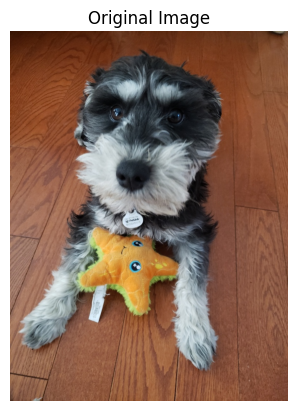

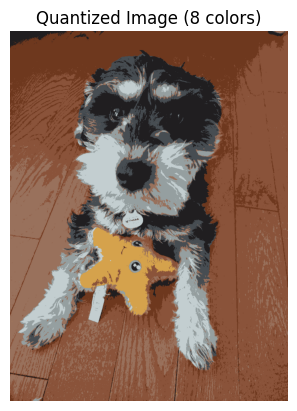

Colors (indices): [0, 1, 2, 3, 4, 5, 6, 7]
Distances: [1, 2]

Correlogram shape: (8, 8, 2)


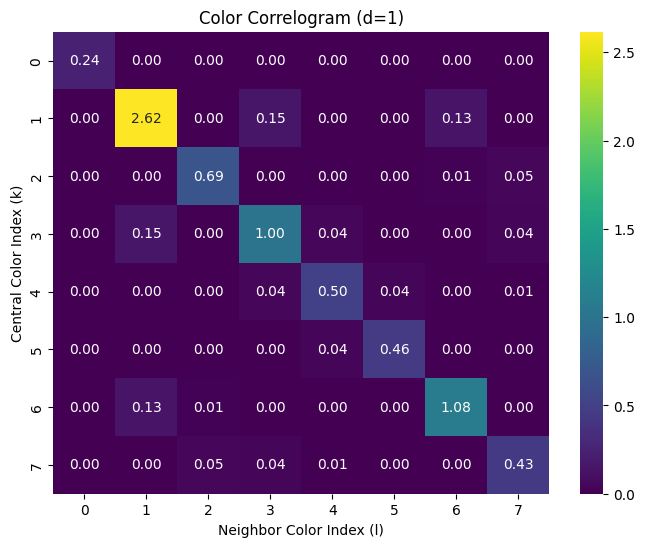

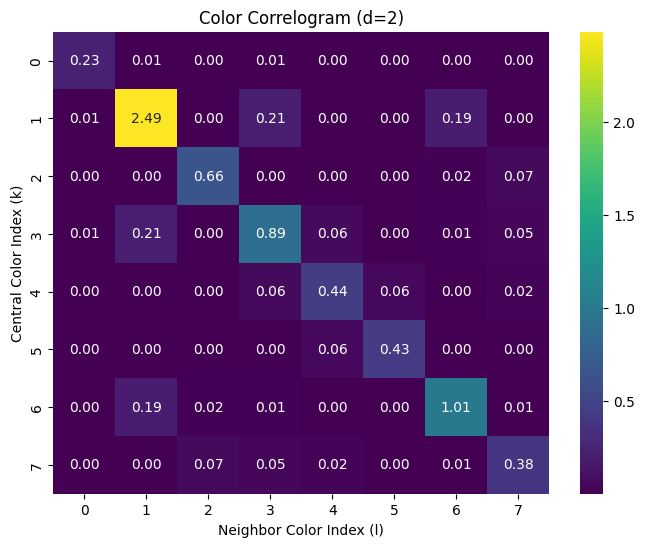


Probability (k=0, l=1, d=1): 0.2388
Autocorrelogram (k=2, d=2): 0.6582


In [ ]:
# @title
import numpy as np
from skimage import io, color
import matplotlib.pyplot as plt
import pandas as pd
import cv2 as cv
import seaborn as sns

work_path = '/content/drive/MyDrive/DigitalImageProcessing/'

image_path=work_path + 'Data/Dog.jpg'
image=io.imread(image_path)
plt.imshow(image)
plt.title("Original Image")
plt.axis('off')
plt.show()

def color_quantization_kmeans(image_path, k_colors):
    """
    Performs color quantization on an image using K-Means clustering.

    Args:
        image_path (str): The path to the input image.
        k_colors (int): The desired number of colors in the quantized image.

    Returns:
        tuple: A tuple containing:
            - numpy.ndarray: The 2D array of color labels (indices from 0 to k_colors-1).
            - numpy.ndarray: The color-quantized image (3D, for display).
    """
    # Load the image
    img = cv.imread(image_path)
    if img is None:
        print(f"Error: Could not load image from {image_path}")
        return None, None

    # Reshape the image to a 2D array of pixels, each with 3 color channels (BGR from OpenCV)
    pixel_data = img.reshape((-1, 3))

    # Convert to float32 for K-Means processing
    pixel_data = np.float32(pixel_data)

    # Define K-Means criteria:
    criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 10, 1.0)

    # Apply K-Means clustering
    compactness, labels, centers = cv.kmeans(
        pixel_data, k_colors, None, criteria, 10, cv.KMEANS_RANDOM_CENTERS)

    # Convert cluster centers back to uint8 (color values)
    centers = np.uint8(centers)

    # Map each pixel's label to its corresponding cluster center color
    quantized_pixels = centers[labels.flatten()]

    # Reshape the quantized pixel data back to the original image dimensions for display
    quantized_image_display = quantized_pixels.reshape((img.shape))

    # Reshape labels to original image dimensions for correlogram calculation
    quantized_labels_2d = labels.reshape(img.shape[:2])

    return quantized_labels_2d, quantized_image_display


def compute_color_correlogram(quantized_indices_image, colors, distances):
    """
    Computes the color correlogram of a quantized image, normalized correctly.
    """
    height, width = quantized_indices_image.shape
    c = len(colors)
    num_distances = len(distances)

    # Initialize the correlogram array with zeros (counts)
    correlogram_counts = np.zeros((c, c, num_distances), dtype=float)
    color_to_idx = {color: i for i, color in enumerate(colors)}

    # Total number of pixels N*M
    total_pixels = height * width

    # Iterate over all pixels p1 in the image
    for m1 in range(height):
        for n1 in range(width):
            p1_color_idx = quantized_indices_image[m1, n1]
            k_idx = color_to_idx[p1_color_idx]

            # Iterate over all neighbors p2 at all specified distances d
            for d_idx, d in enumerate(distances):
                # Check 8 neighbors at distance d (relative coordinates)
                for dm in [-d, 0, d]:
                    for dn in [-d, 0, d]:
                        if dm == 0 and dn == 0:
                            continue
                        m2, n2 = m1 + dm, n1 + dn

                        # Check bounds
                        if 0 <= m2 < height and 0 <= n2 < width:
                            p2_color_idx = quantized_indices_image[m2, n2]
                            l_idx = color_to_idx[p2_color_idx]
                            # Increment the count for this specific k, l, d
                            correlogram_counts[k_idx, l_idx, d_idx] += 1

    # Normalize the entire 3D array by the total number of pixels in the image
    # This yields the joint probability P(p1 color is k AND p2 color is l)
    correlogram = correlogram_counts

    return correlogram, total_pixels

if __name__ == "__main__":
    # Example usage:
    num_colors = 8  # Desired number of colors

    # Call color_quantization_kmeans with the image path
    quantized_labels, quantized_img_display = color_quantization_kmeans(image_path, num_colors)

    if quantized_labels is not None and quantized_img_display is not None:
        plt.imshow(cv.cvtColor(quantized_img_display, cv.COLOR_BGR2RGB)) # Convert BGR to RGB for matplotlib display
        plt.title(f"Quantized Image ({num_colors} colors)")
        plt.axis('off')
        plt.show()

        # Prepare for compute_color_correlogram
        # 'colors' should be the range of integer indices produced by k-means
        quantized_color_indices_range = list(range(num_colors))
        check_distances = [1, 2]

        # Compute the correlogram using the 2D quantized labels (indices)
        # Fix: Unpack the returned tuple correctly and then perform division
        correlogram_counts, total_pixels_count = compute_color_correlogram(quantized_labels, quantized_color_indices_range, check_distances)
        gamma = correlogram_counts / total_pixels_count

        # 3. Print results (example for gamma^d_{k,l} for specific k, l, d)
        print(f"Colors (indices): {quantized_color_indices_range}")
        print(f"Distances: {check_distances}")
        print(f"\nCorrelogram shape: {gamma.shape}")

        # Visualize each slice of the correlogram as a heatmap
        for d_idx, d_val in enumerate(check_distances):
            plt.figure(figsize=(8, 6))
            sns.heatmap(gamma[:, :, d_idx],
                        annot=True, fmt=".2f", cmap="viridis",
                        xticklabels=quantized_color_indices_range,
                        yticklabels=quantized_color_indices_range)
            plt.title(f"Color Correlogram (d={d_val})")
            plt.xlabel("Neighbor Color Index (l)")
            plt.ylabel("Central Color Index (k)")
            plt.show()

        # Example: Probability a pixel of color 0 has a neighbor of color 1 at distance 1
        if num_colors > 1 and len(check_distances) > 0:
            k_idx_0 = 0 # Using 0-based indices for quantized colors
            l_idx_1 = 0
            d_idx_1 = check_distances.index(1) if 1 in check_distances else -1
            if d_idx_1 != -1:
                prob_0_1_d1 = gamma[k_idx_0, l_idx_1, d_idx_1]
                print(f"\nProbability (k=0, l=1, d=1): {prob_0_1_d1:.4f}")

        # Example: Autocorrelogram value for color 2 at distance 2
        if num_colors > 2 and len(check_distances) > 1:
            k_idx_2 = 2
            l_idx_2 = 2
            d_idx_2 = check_distances.index(2) if 2 in check_distances else -1
            if d_idx_2 != -1:
                prob_2_2_d2 = gamma[k_idx_2, l_idx_2, d_idx_2]
                print(f"Autocorrelogram (k=2, d=2): {prob_2_2_d2:.4f}")

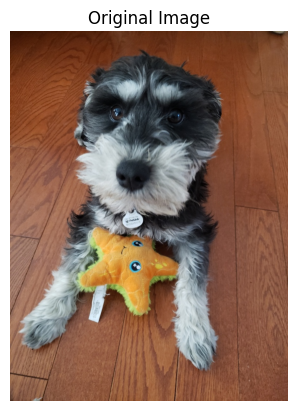

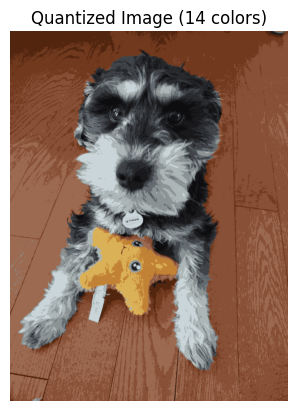

Colors (indices): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
Distances: [1, 2, 3]

Correlogram (gamma) shape: (14, 14, 3)  # (k, l, d)


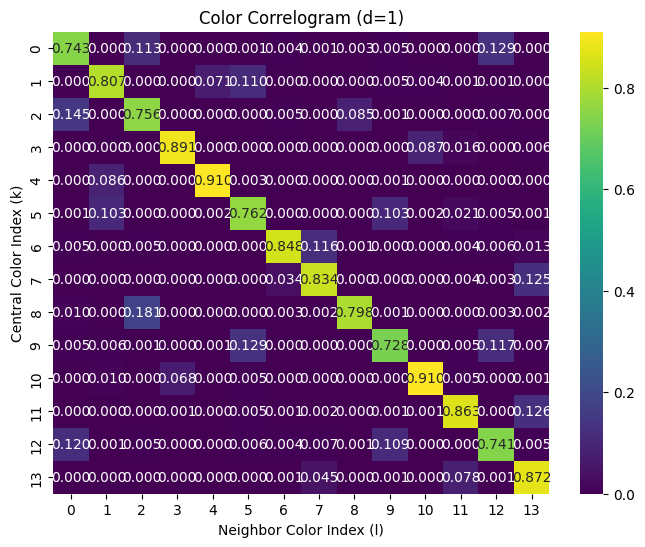

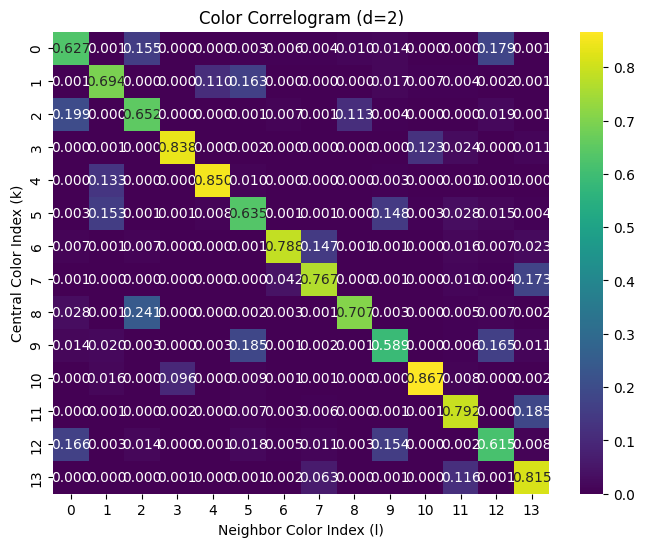

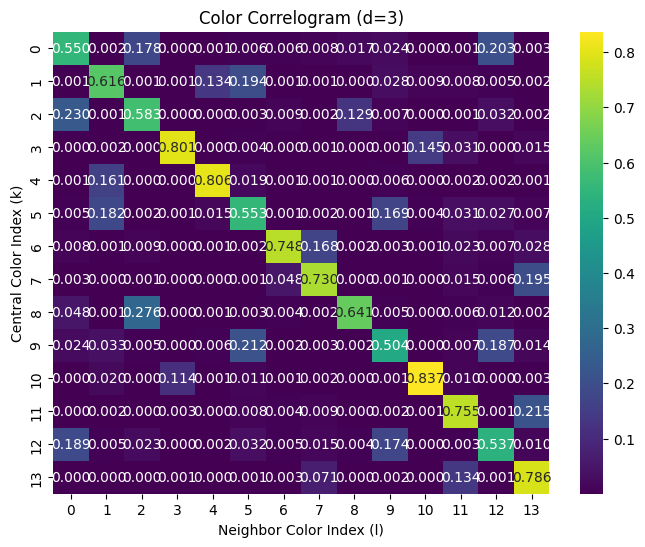


Probability (k=0, l=1, d=1): 0.0003
Autocorrelogram (k=2, d=2): 0.6525


In [ ]:
import numpy as np
from skimage import io
import matplotlib.pyplot as plt
import cv2 as cv
import seaborn as sns

work_path = '/content/drive/MyDrive/DigitalImageProcessing/'

image_path = work_path + 'Data/Dog.jpg'


def color_quantization_kmeans(image_path, k_colors):
    """
    Performs color quantization on an image using K-Means clustering.

    Args:
        image_path (str): The path to the input image.
        k_colors (int): The desired number of colors in the quantized image.

    Returns:
        tuple: A tuple containing:
            - numpy.ndarray: The 2D array of color labels (indices from 0 to k_colors-1).
            - numpy.ndarray: The color-quantized image (3D, for display).
    """
    # Load the image (OpenCV reads as BGR)
    img = cv.imread(image_path)
    if img is None:
        print(f"Error: Could not load image from {image_path}")
        return None, None

    # Reshape the image to a 2D array of pixels, each with 3 color channels (BGR from OpenCV)
    pixel_data = img.reshape((-1, 3)).astype(np.float32)

    # Define K-Means criteria:
    criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 10, 1.0)

    # Apply K-Means clustering
    compactness, labels, centers = cv.kmeans(
        pixel_data, k_colors, None, criteria, 10, cv.KMEANS_RANDOM_CENTERS)

    # Convert cluster centers back to uint8 (color values)
    centers = np.uint8(centers)

    # Map each pixel's label to its corresponding cluster center color
    quantized_pixels = centers[labels.flatten()]

    # Reshape the quantized pixel data back to the original image dimensions for display
    quantized_image_display = quantized_pixels.reshape((img.shape))

    # Reshape labels to original image dimensions (labels are cluster indices)
    quantized_labels_2d = labels.reshape(img.shape[:2])

    return quantized_labels_2d, quantized_image_display


def compute_color_correlogram(quantized_image, colors, distances=[1]):
    """
    Computes the color correlogram for the given quantized 2D label image.

    Args:
        quantized_image (np.ndarray): 2D array of quantized color indices (shape: H x W).
        colors (iterable): Iterable of color indices present (e.g., range(k)).
        distances (list or iterable): List of integer distances to compute correlogram for.

    Returns:
        tuple:
            - correlogram_counts: np.ndarray of shape (num_colors, num_colors, num_distances)
              where correlogram_counts[k, l, d_idx] is the number of neighbor occurrences
              of color l around central color k at distance distances[d_idx].
            - total_neighbors: np.ndarray of shape (num_colors, num_distances) giving the
              total number of neighbor positions examined for each central color k and distance d.
    Notes:
        The correlogram values can be normalized by dividing correlogram_counts by
        total_neighbors[:, np.newaxis, :] (take care to avoid division by zero).
    """
    height, width = quantized_image.shape
    colors = list(colors)
    num_colors = len(colors)
    distances = list(distances)
    num_dist = len(distances)

    # Preallocate arrays
    correlogram_counts = np.zeros((num_colors, num_colors, num_dist), dtype=np.float64)
    total_neighbors = np.zeros((num_colors, num_dist), dtype=np.float64)

    # Map color value -> index in colors list (in case colors are not 0..K-1)
    color_to_idx = {c: i for i, c in enumerate(colors)}

    # For each central color, get coordinates once
    coords_by_color = {}
    for c in colors:
        coords = np.argwhere(quantized_image == c)
        coords_by_color[c] = coords

    # For each distance, define the 8 discrete directions on the "ring" of radius d
    for d_idx, d in enumerate(distances):
        offsets = [(-d, -d), (-d, 0), (-d, d),
                   (0, -d), (0, d),
                   (d, -d), (d, 0), (d, d)]

        for c_k in colors:
            k_idx = color_to_idx[c_k]
            coords = coords_by_color[c_k]
            if coords.size == 0:
                # No pixels of this color in the image
                continue

            for (m1, n1) in coords:
                for (dm, dn) in offsets:
                    m2, n2 = m1 + dm, n1 + dn
                    if 0 <= m2 < height and 0 <= n2 < width:
                        total_neighbors[k_idx, d_idx] += 1
                        neighbor_color = quantized_image[m2, n2]
                        # Only count if neighbor_color is among provided colors
                        if neighbor_color in color_to_idx:
                            l_idx = color_to_idx[neighbor_color]
                            correlogram_counts[k_idx, l_idx, d_idx] += 1

    return correlogram_counts, total_neighbors


if __name__ == "__main__":
    # Show original image (using skimage.io for display convenience)
    img_for_display = io.imread(image_path)
    plt.imshow(img_for_display)
    plt.title("Original Image")
    plt.axis('off')
    plt.show()

    # Example usage:
    num_colors = 14  # Desired number of colors

    # Call color_quantization_kmeans with the image path
    quantized_labels, quantized_img_display = color_quantization_kmeans(image_path, num_colors)

    if quantized_labels is not None and quantized_img_display is not None:
        plt.imshow(cv.cvtColor(quantized_img_display, cv.COLOR_BGR2RGB))  # Convert BGR to RGB for matplotlib display
        plt.title(f"Quantized Image ({num_colors} colors)")
        plt.axis('off')
        plt.show()

        # Prepare for compute_color_correlogram
        quantized_color_indices_range = list(range(num_colors))
        check_distances = [1, 2, 3]

        # Compute the correlogram using the 2D quantized labels (indices)
        correlogram_counts, total_neighbors = compute_color_correlogram(
            quantized_labels, quantized_color_indices_range, check_distances)

        # Normalize: avoid division by zero
        # total_neighbors shape: (num_colors, num_distances)
        # correlogram_counts shape: (num_colors, num_colors, num_distances)
        denom = total_neighbors[:, np.newaxis, :]  # shape (num_colors,1,num_distances) for broadcasting
        with np.errstate(divide='ignore', invalid='ignore'):
            gamma = np.divide(correlogram_counts, denom)
            gamma = np.nan_to_num(gamma, nan=0.0, posinf=0.0, neginf=0.0)

        print(f"Colors (indices): {quantized_color_indices_range}")
        print(f"Distances: {check_distances}")
        print(f"\nCorrelogram (gamma) shape: {gamma.shape}  # (k, l, d)")

        # Visualize each slice of the correlogram as a heatmap
        for d_idx, d_val in enumerate(check_distances):
            plt.figure(figsize=(8, 6))
            sns.heatmap(gamma[:, :, d_idx],
                        annot=True, fmt=".3f", cmap="viridis",
                        xticklabels=quantized_color_indices_range,
                        yticklabels=quantized_color_indices_range)
            plt.title(f"Color Correlogram (d={d_val})")
            plt.xlabel("Neighbor Color Index (l)")
            plt.ylabel("Central Color Index (k)")
            plt.show()

        # Example: Probability a pixel of color 0 has a neighbor of color 1 at distance 1
        if num_colors > 1 and len(check_distances) > 0:
            k_idx_0 = 0  # central color index
            l_idx_1 = 1  # neighbor color index
            if 1 in check_distances:
                d_idx_1 = check_distances.index(1)
                prob_0_1_d1 = gamma[k_idx_0, l_idx_1, d_idx_1]
                print(f"\nProbability (k=0, l=1, d=1): {prob_0_1_d1:.4f}")

        # Example: Autocorrelogram value for color 2 at distance 2
        if num_colors > 2 and 2 in check_distances:
            k_idx_2 = 2
            d_idx_2 = check_distances.index(2)
            prob_2_2_d2 = gamma[k_idx_2, k_idx_2, d_idx_2]
            print(f"Autocorrelogram (k=2, d=2): {prob_2_2_d2:.4f}")